# Apt 305 — the AU corrections on a **closed** energy balance

Runs the seven-state harness end to end and checks the hard gate:

> **V2 Sankey closure residual < 5 % on the canonical baseline and every
> downstream state.** Until that passes, no reduction percentage and no
> kWh/m² headline from this model is a result.

What is being fixed, and why the earlier numbers could not be trusted:

| | |
| --- | --- |
| **Defect A** | The five party surfaces — 75.10 m², **88.6 % of the envelope UA** — were in the solver but in neither side of the reported balance. The Sankey listed two transmission entries for a building with seven surfaces. |
| **also A** | Transmission was read at each element's *internal* face while the gains were counted in full, so the radiative fractions ISO 52016-1 formula (39) deposits straight onto the surface nodes were invisible to it — 1 084.58 kWh, exactly. |
| **Defect B** | Latent cooling was charged in 8 758 of 8 760 hours against ~146 hours of actual plant operation. A moisture balance reported as plant energy, inflating the headline ~5×. |
| **Upstream** | `sky_view_factor == 0` was read as *slab-on-ground*, burying a third-floor apartment's ceiling in the earth and producing two irreconcilable baselines from one building. |

**Runtime: roughly 5–10 minutes.** Seven full annual simulations, one engine
worktree per state.

Runtime type: CPU is fine — there is nothing here a GPU would help with.

## 1 · Setup

In [1]:
import os, subprocess, sys
from pathlib import Path

REPO   = Path('/content/AIB')
BRANCH = 'claude/aib-energy-balance-closure-83epu7'   # the closed-balance branch

if not REPO.exists():
    subprocess.run(['git', 'clone',
                    'https://github.com/samiraghafarigousheh-sys/aib.git', str(REPO)],
                   check=True)
os.chdir(REPO)

# Every branch, not just the default one: the harness builds one worktree per
# state and each state IS a branch.
subprocess.run(['git', 'fetch', 'origin', '+refs/heads/*:refs/remotes/origin/*'],
               check=True)
subprocess.run(['git', 'checkout', BRANCH], check=True)

# Colab already ships numpy, pandas, matplotlib, plotly, tqdm and pytest.
# These four are the gaps.
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'pvlib', 'timezonefinder', 'holidays', 'workalendar'], check=True)

print(subprocess.run(['git', 'log', '--oneline', '-5'],
                     capture_output=True, text=True).stdout)
print('weather:', *[p.name for p in Path('weather_cache').glob('*.epw')])

b00e9a3 Colab notebook for the closed-balance harness
fbbd226 Closed-balance six-state harness, report and chart
9fd8c69 Upstream: a surface is ground contact only when it declares a ground boundary
82a909d Defect B: gate latent conditioning to hours the plant actually runs
6e549fa Defect A: tally ADJ surface transmission and close the Sankey control volume

weather: AUS_VIC_Melbourne.RO.948680_TMYx.2011-2025.epw


## 2 · Run the harness

Seven states. For each one the engine branch is checked out into its own
worktree and the three **closure commits are cherry-picked on top**, so the
reporting instrument is identical across states while the physics fix under
test varies. Watch the `resid=` column: it is the whole point of the run.

In [2]:
EPW = 'weather_cache/AUS_VIC_Melbourne.RO.948680_TMYx.2011-2025.epw'

proc = subprocess.Popen(
    [sys.executable, 'tools/diagnostics/closed_balance_six_state.py',
     '--weather', EPW, '--outdir', 'results/au_corrections_closed'],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)

for line in proc.stdout:          # stream, rather than going quiet for ten minutes
    print(line, end='')
proc.wait()

print('\nexit code:', proc.returncode,
      '— 0 = gate passed on every state, 2 = at least one state failed')

no closure commits found in origin/main..HEAD

exit code: 1 — 0 = gate passed on every state, 2 = at least one state failed


## 3 · The gate

In [3]:
import json
import pandas as pd

RAW = Path('results/au_corrections_closed/six_state_closed_raw.json')
blob = json.loads(RAW.read_text())
results, meta = blob['results'], blob['meta']

# What the same column read before these fixes, for contrast.
BEFORE = {'Baseline': 62.41, '+Vent+Latent': 58.61, '+Internal Gains': 52.06,
          '+Conditioned Zones': -22.52, '+Ground Fix': -19.64, '+Hemisphere Fix': -19.64}

rows = []
for state, r in results.items():
    b, sk = r['config_B'], r['config_B']['sankey']
    rows.append({
        'State': state,
        'Inputs (kWh)':  sk['inputs_total_Wh'] / 1000,
        'Outputs (kWh)': sk['outputs_total_Wh'] / 1000,
        'Residual (kWh)': sk['residual_kWh'],
        'Residual %': sk['residual_pct'],
        'Was %': BEFORE.get(state, float('nan')),
        'Transmission items': sk['n_transmission_items'],
        'Gate': 'PASS' if abs(sk['residual_pct']) < 5.0 else 'FAIL',
    })

gate = pd.DataFrame(rows)
display(gate.style.format({
    'Inputs (kWh)': '{:,.2f}', 'Outputs (kWh)': '{:,.2f}',
    'Residual (kWh)': '{:+,.2f}', 'Residual %': '{:+.2f} %', 'Was %': '{:+.2f} %',
}, na_rep='— (new state)').hide(axis='index'))

assert (gate['Gate'] == 'PASS').all(), 'GATE FAILED — do not quote a headline from this run'
print('\nGate passed on all', len(gate), 'states.')
print('Every state now lists', gate['Transmission items'].iloc[0],
      'transmission line items; before the fix it was 2, for a building with 7 surfaces.')

State,Inputs (kWh),Outputs (kWh),Residual (kWh),Residual %,Was %,Transmission items,Gate
Baseline,"7,882.02","7,969.45",-87.42,-1.11 %,+62.41 %,7,PASS
+Vent+Latent,"8,065.33","8,146.75",-81.42,-1.01 %,+58.61 %,7,PASS
+Internal Gains,"5,276.34","5,331.66",-55.32,-1.05 %,+52.06 %,7,PASS
+Conditioned Zones,"3,864.43","3,931.04",-66.61,-1.72 %,-22.52 %,7,PASS
+Ground Fix,"3,862.23","3,862.23",-0.00,-0.00 %,-19.64 %,7,PASS
+Hemisphere Fix,"3,862.23","3,862.23",-0.00,-0.00 %,-19.64 %,7,PASS
+Closure Fixes (HEAD),"4,007.25","4,007.25",-0.00,-0.00 %,— (new state),7,PASS



Gate passed on all 7 states.
Every state now lists 7 transmission line items; before the fix it was 2, for a building with 7 surfaces.


### What the residual that survives is made of

On the four states *before* the ground fix the residual is not noise. It is the
phantom ground term — a lumped `h_ground · (T_in − T_gr)` flow computed from a
slab area that `_ground_contact_area()` filled in from `net_floor_area` because
no surface carried a ground tag, with no `GR` element behind it in the solver.

In [4]:
comp = pd.DataFrame([{
    'State': s,
    'Residual (kWh)': r['config_B']['sankey']['residual_kWh'],
    '−(ground loss − gain) (kWh)': -((r['config_B'].get('Q_ground_loss_kWh') or 0.0)
                                     - (r['config_B'].get('Q_ground_gain_kWh') or 0.0)),
} for s, r in results.items()])
comp['|Δ| (kWh)'] = (comp['Residual (kWh)'] - comp['−(ground loss − gain) (kWh)']).abs()

display(comp.style.format({
    'Residual (kWh)': '{:+,.2f}', '−(ground loss − gain) (kWh)': '{:+,.2f}',
    '|Δ| (kWh)': '{:.2e}'}).hide(axis='index'))

print('They match to within', f"{comp['|Δ| (kWh)'].max():.1e}", 'kWh — the same term, twice.')
print('The ground fix removes it and the residual goes to zero: the +66.61 kWh')
print('effect the Item 3 diagnosis attributed to it, now measured on a balance')
print('where it is the only thing left to remove.')

State,Residual (kWh),−(ground loss − gain) (kWh),|Δ| (kWh)
Baseline,-87.42,-87.42,3.92e-11
+Vent+Latent,-81.42,-81.42,1.68e-12
+Internal Gains,-55.32,-55.32,1.67e-11
+Conditioned Zones,-66.61,-66.61,9.99e-12
+Ground Fix,-0.00,-0.00,1.40e-12
+Hemisphere Fix,-0.00,-0.00,1.40e-12
+Closure Fixes (HEAD),-0.00,-0.00,9.31e-13


They match to within 3.9e-11 kWh — the same term, twice.
The ground fix removes it and the residual goes to zero: the +66.61 kWh
effect the Item 3 diagnosis attributed to it, now measured on a balance
where it is the only thing left to remove.


## 4 · Energy need, sensible and latent kept apart

In [5]:
need = pd.DataFrame([{
    'State': s,
    'Sensible heating (kWh)': r['config_B']['Q_H_sensible_kWh'],
    'Sensible cooling (kWh)': r['config_B']['Q_C_sensible_kWh'],
    'Latent cooling, gated (kWh)': r['config_B']['Q_C_latent_kWh'],
    'Latent cooling, ungated (kWh)': r['config_B']['Q_C_latent_ungated_kWh'],
    'Latent heating (kWh)': r['config_B']['Q_H_latent_kWh'],
    'Total (kWh)': r['config_B']['Q_need_total_kWh'],
    'Total (kWh/m²)': r['config_B']['Q_need_total_kWh_per_sqm'],
} for s, r in results.items()])

display(need.style.format({c: '{:,.2f}' for c in need.columns if c != 'State'}
                          | {'Latent heating (kWh)': '{:,.4f}'}).hide(axis='index'))

head = need.iloc[-1]
print(f"Final state: {head['Sensible heating (kWh)']:.2f} + {head['Sensible cooling (kWh)']:.2f} "
      f"sensible + {head['Latent cooling, gated (kWh)']:.2f} latent "
      f"= {head['Total (kWh)']:.2f} kWh ({head['Total (kWh/m²)']:.2f} kWh/m²·yr)")
print("The ungated definition reported 697.10 kWh / 34.85 kWh/m² for the same run.")

State,Sensible heating (kWh),Sensible cooling (kWh),"Latent cooling, gated (kWh)","Latent cooling, ungated (kWh)",Latent heating (kWh),Total (kWh),Total (kWh/m²)
Baseline,"1,308.60",741.83,55.76,617.38,157.9951,"2,264.18",113.21
+Vent+Latent,"1,522.61",646.25,29.21,404.21,0.0117,"2,198.08",109.90
+Internal Gains,"3,228.23",308.30,15.85,670.63,0.0450,"3,552.43",177.62
+Conditioned Zones,123.39,20.06,2.29,553.62,0.0000,145.74,7.29
+Ground Fix,123.39,20.06,2.29,553.62,0.0000,145.74,7.29
+Hemisphere Fix,123.39,20.06,2.29,553.62,0.0000,145.74,7.29
+Closure Fixes (HEAD),122.69,67.12,3.98,554.62,0.0000,193.79,9.69


Final state: 122.69 + 67.12 sensible + 3.98 latent = 193.79 kWh (9.69 kWh/m²·yr)
The ungated definition reported 697.10 kWh / 34.85 kWh/m² for the same run.


### The latent gate

Latent cooling is charged only where **both** hold: the cooling plant is running
(`Q_C > 0`) and the moisture balance actually calls for dehumidification. The two
columns that have to be zero are the last two.

In [6]:
lat = pd.DataFrame([{
    'State': s,
    'Steps': r['config_B'].get('n_steps'),
    'Cooling plant on': r['config_B'].get('n_steps_cooling_on'),
    'Latent charged': r['config_B'].get('n_steps_latent_charged'),
    'Gated (kWh)': r['config_B']['Q_C_latent_kWh'],
    'Ungated (kWh)': r['config_B']['Q_C_latent_ungated_kWh'],
    'Charged w/ cooling OFF': r['config_B'].get('latent_kWh_with_cooling_off'),
    'Charged while HEATING': r['config_B'].get('latent_kWh_while_heating'),
} for s, r in results.items()])
display(lat.style.format({'Gated (kWh)': '{:,.2f}', 'Ungated (kWh)': '{:,.2f}',
                          'Charged w/ cooling OFF': '{:.4f}',
                          'Charged while HEATING': '{:.4f}'}).hide(axis='index'))

assert lat['Charged w/ cooling OFF'].abs().max() < 1e-9
assert lat['Charged while HEATING'].abs().max() < 1e-9
print('Zero with the plant off, zero while the heating plant runs — in every state.')

# The gate must not have inverted the seasonal phase.
import calendar
monthly = results[list(results)[-1]]['config_B'].get('monthly_latent_cooling_kWh')
if monthly:
    peak = max(range(12), key=lambda i: monthly[i]) + 1
    print(f'Monthly latent cooling peaks in {calendar.month_name[peak]} '
          f'— southern-hemisphere phase retained.')

State,Steps,Cooling plant on,Latent charged,Gated (kWh),Ungated (kWh),Charged w/ cooling OFF,Charged while HEATING
Baseline,8760,1030,288,55.76,617.38,0.0000,0.0000
+Vent+Latent,8760,921,917,29.21,404.21,0.0000,0.0000
+Internal Gains,8760,463,463,15.85,670.63,0.0000,0.0000
+Conditioned Zones,8760,66,64,2.29,553.62,0.0000,0.0000
+Ground Fix,8760,66,64,2.29,553.62,0.0000,0.0000
+Hemisphere Fix,8760,66,64,2.29,553.62,0.0000,0.0000
+Closure Fixes (HEAD),8760,146,146,3.98,554.62,0.0000,0.0000


Zero with the plant off, zero while the heating plant runs — in every state.
Monthly latent cooling peaks in January — southern-hemisphere phase retained.


## 5 · The adjacent-zone surfaces are in the inventory

75.10 m², 88.6 % of the envelope UA, previously absent from both sides. The last
column is the consistency check the plan asked for: the Sankey's transmission
line items against an **independent** re-integration of the per-surface flows
from the hourly frame — two different aggregation paths, tolerance 0.1 %.

In [7]:
adj = pd.DataFrame([{
    'State': s,
    'ADJ loss (kWh)': r['config_B'].get('Q_tr_adjacent_loss_kWh'),
    'ADJ gain (kWh)': r['config_B'].get('Q_tr_adjacent_gain_kWh'),
    'Line items': r['config_B']['sankey']['n_transmission_items'],
    'Reported Σ (kWh)': r['config_B']['sankey']['transmission_reported_kWh'],
    'Independent Σ (kWh)': r['config_B']['sankey']['transmission_independent_kWh'],
    'Δ %': 100 * r['config_B']['sankey']['transmission_rel_diff'],
} for s, r in results.items()])
display(adj.style.format({'ADJ loss (kWh)': '{:,.2f}', 'ADJ gain (kWh)': '{:,.2f}',
                          'Reported Σ (kWh)': '{:,.2f}', 'Independent Σ (kWh)': '{:,.2f}',
                          'Δ %': '{:.4f} %'}).hide(axis='index'))

# The per-surface inventory of the final state, in full.
print('\nFinal-state transmission line items (kWh):')
for name, kwh in sorted(results[list(results)[-1]]['config_B']['sankey']
                        ['transmission_items_kWh'].items(), key=lambda kv: -kv[1]):
    print(f'  {name:<58} {kwh:9.2f}')

print('\nISO 52016-1 element class per surface:')
for name, t in results[list(results)[-1]]['config_B']['sankey']['surface_iso_types'].items():
    print(f'  {name:<58} {t}')

State,ADJ loss (kWh),ADJ gain (kWh),Line items,Reported Σ (kWh),Independent Σ (kWh),Δ %
Baseline,"4,554.61",2.82,7,"5,267.01","5,267.01",0.0000 %
+Vent+Latent,"4,351.27",2.82,7,"5,036.69","5,036.69",0.0000 %
+Internal Gains,"2,689.41",5.83,7,"3,162.27","3,162.27",0.0000 %
+Conditioned Zones,"1,056.86","1,686.33",7,"1,744.29","1,744.29",0.0000 %
+Ground Fix,"1,056.86","1,686.33",7,"1,744.29","1,744.29",0.0000 %
+Hemisphere Fix,"1,056.86","1,686.33",7,"1,744.29","1,744.29",0.0000 %
+Closure Fixes (HEAD),"1,135.23","1,688.70",7,"1,818.21","1,818.21",0.0000 %



Final-state transmission line items (kWh):
  Transmission - West exterior wall (opaque)                    400.93
  Transmission - West window - fixed + West window - operable    281.77
  Transmission - Floor to Apt 205                               248.79
  Transmission - Ceiling to Apt 405                             248.79
  Transmission - East wall to corridor                          245.35
  Transmission - North wall to Apt 306                          196.28
  Transmission - South wall to Apt 304                          196.28

ISO 52016-1 element class per surface:
  West exterior wall (opaque)                                OP
  North wall to Apt 306                                      ADJ
  South wall to Apt 304                                      ADJ
  East wall to corridor                                      ADJ
  Floor to Apt 205                                           ADJ
  Ceiling to Apt 405                                         ADJ
  West window - fixed + West 

## 6 · Config A / config B convergence

Config A types the five party surfaces `"opaque"`; config B types them
`"adjacent"`. Before the classification fix, config A buried all five as
slab-on-ground and returned **15.86 kWh heating / 2 027.5 kWh cooling** against
config B's 1 308.60 / 741.83 — one building, two irreconcilable baselines.

In [8]:
conv_state = next((s for s, r in results.items() if 'config_A' in r), None)
if conv_state is None:
    print('no config-A run in this output')
else:
    A, B = results[conv_state]['config_A'], results[conv_state]['config_B']
    keys = ['Q_H_sensible_kWh', 'Q_C_sensible_kWh', 'Q_need_total_kWh',
            'Q_tr_adjacent_loss_kWh', 'Q_ground_loss_kWh']
    conv = pd.DataFrame([{'Metric': k, 'Config A': A[k], 'Config B': B[k],
                          'Difference': abs(A[k] - B[k])} for k in keys])
    display(conv.style.format({'Config A': '{:,.6f}', 'Config B': '{:,.6f}',
                               'Difference': '{:.3e}'}).hide(axis='index'))

    gr_a = [n for n, t in A['sankey']['surface_iso_types'].items() if t == 'GR']
    gr_b = [n for n, t in B['sankey']['surface_iso_types'].items() if t == 'GR']
    print(f'Surfaces classified GR — config A: {gr_a or "none"}, config B: {gr_b or "none"}')
    print('Converged bit-exactly.' if conv['Difference'].max() == 0
          else f"Largest difference: {conv['Difference'].max():.3e} kWh")

Metric,Config A,Config B,Difference
Q_H_sensible_kWh,122.691925,122.691925,0.000e+00
Q_C_sensible_kWh,67.121099,67.121099,0.000e+00
Q_need_total_kWh,193.788899,193.788899,0.000e+00
Q_tr_adjacent_loss_kWh,"1,135.233741","1,135.233741",0.000e+00
Q_ground_loss_kWh,0.000000,0.000000,0.000e+00


Surfaces classified GR — config A: none, config B: none
Converged bit-exactly.


## 7 · The chart

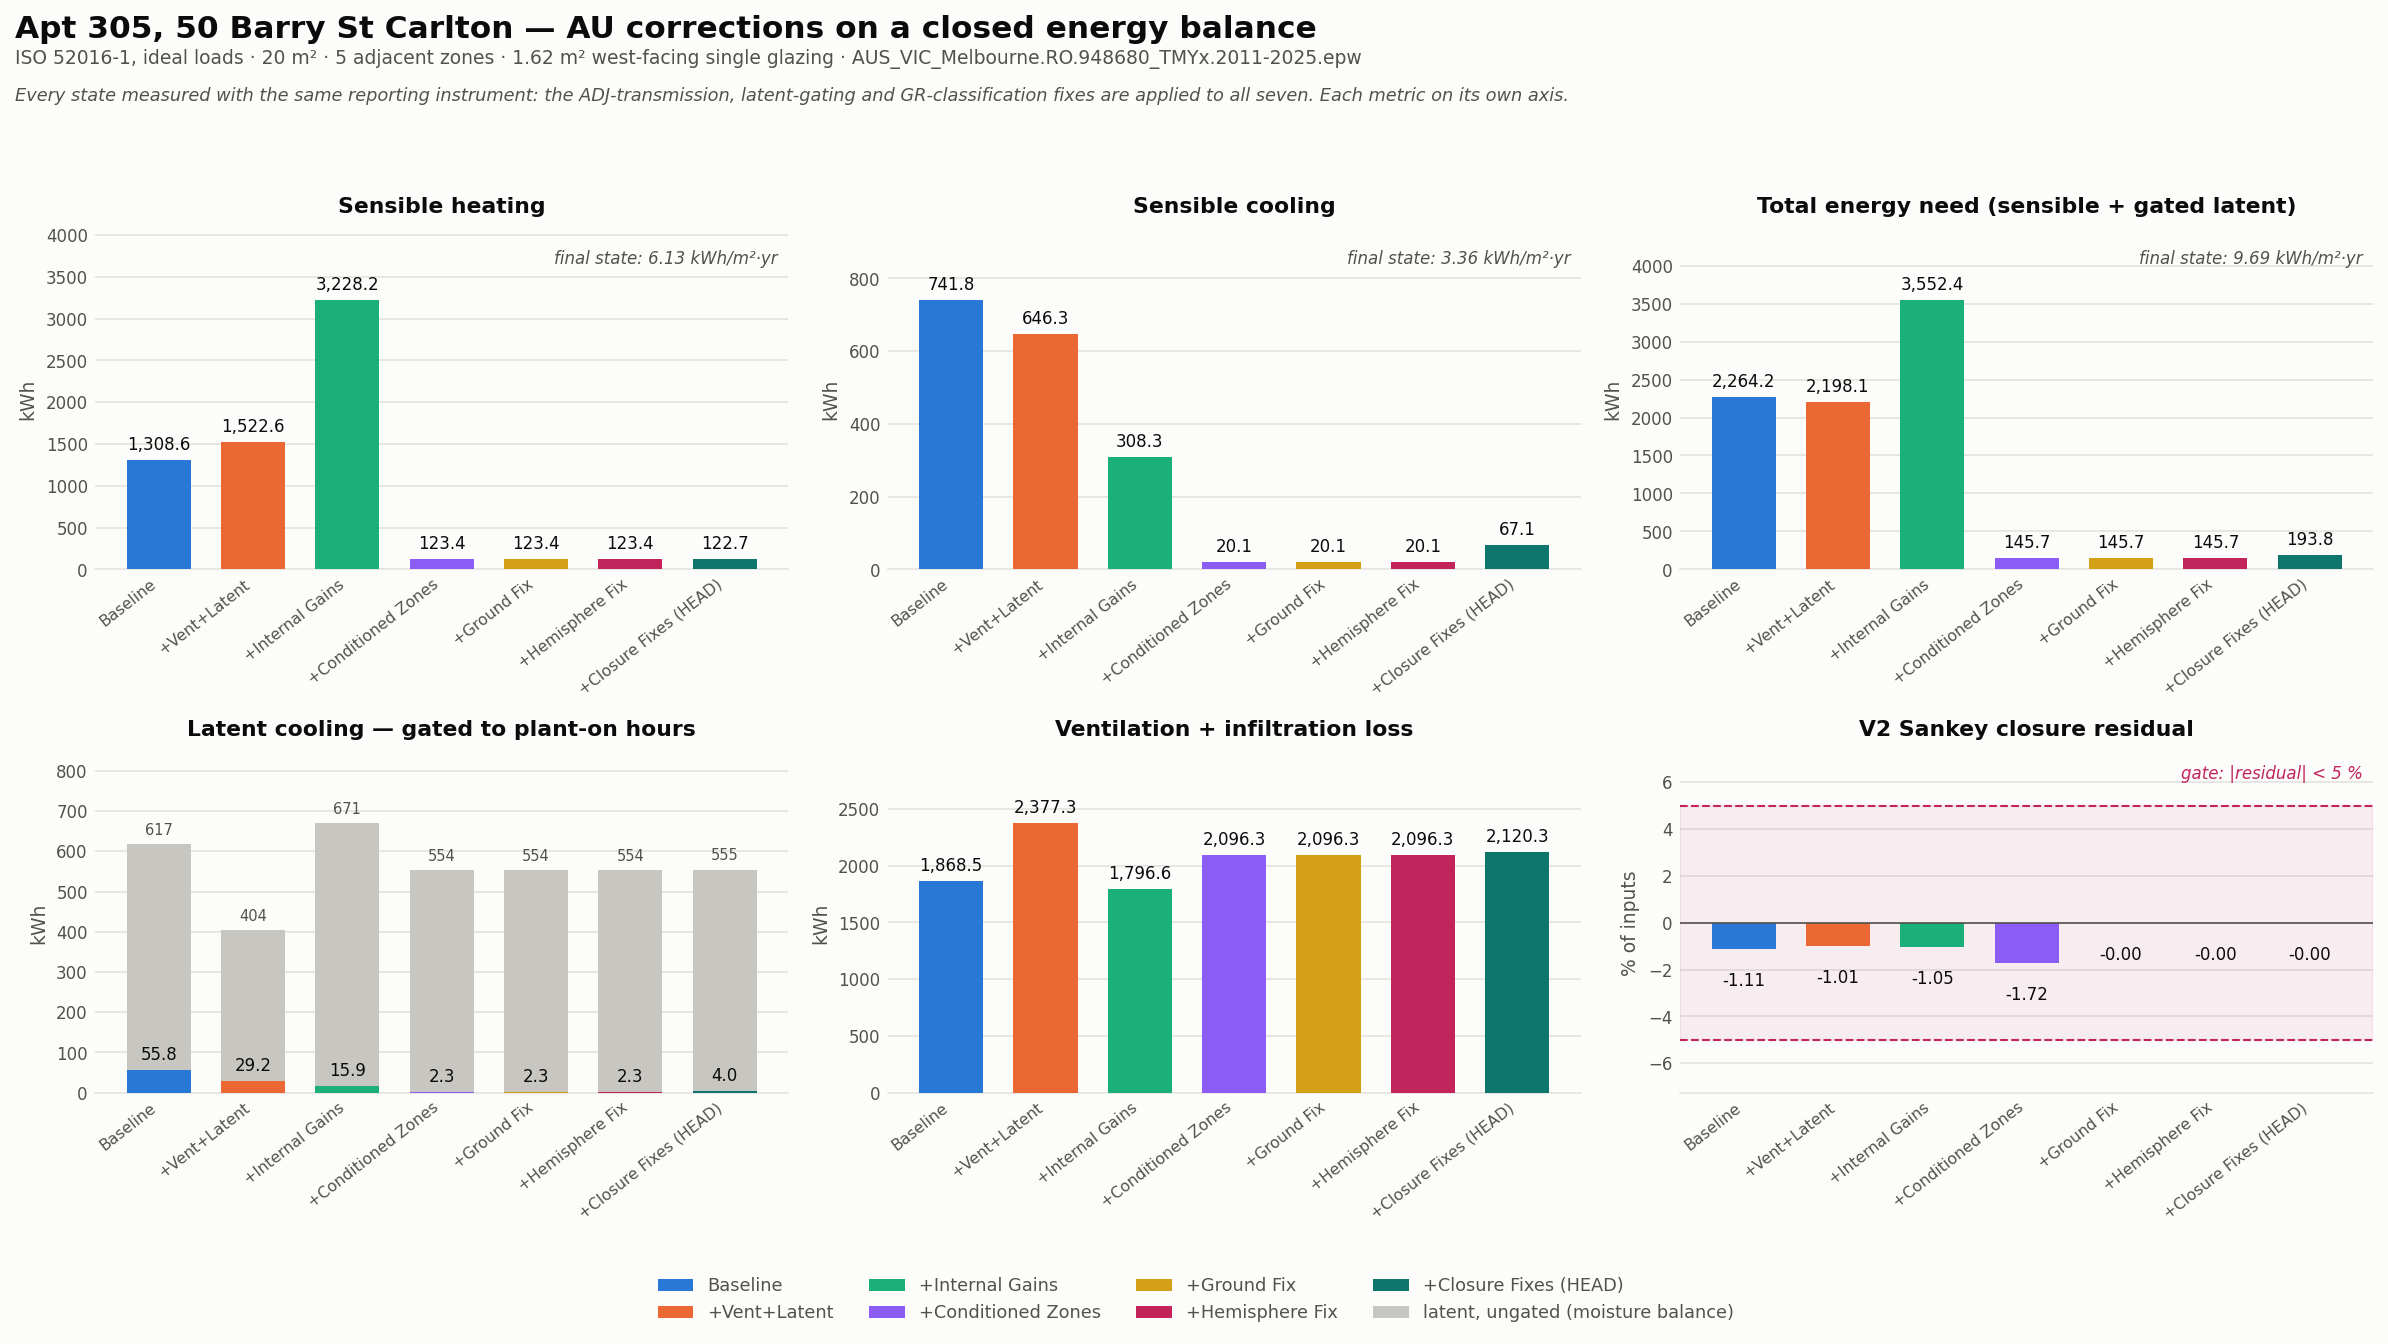

In [9]:
subprocess.run([sys.executable, 'tools/diagnostics/make_closed_balance_chart.py'], check=True)

from IPython.display import Image, display
display(Image('results/au_corrections_closed/au_corrections_closed_balance.png'))

## 8 · The regression tests

These are the assertions behind the tables above — the ADJ surfaces present as
line items, the 0.1 % consistency check, the gate, the latent gating, the
classifier, and config A/B convergence. Plus a ground-floor building, so the
ADJ fix cannot be a blanket "ground is always zero".

In [10]:
env = dict(os.environ, PYTHONPATH=str(REPO / 'pybuildingenergy' / 'src'))
subprocess.run([sys.executable, '-m', 'pytest',
                'tests/test_sankey_closure_adj_transmission.py',
                'tests/test_latent_gating.py',
                'tests/test_gr_classification.py',
                '-v', '--no-header', '-p', 'no:cacheprovider'], env=env)

CompletedProcess(args=['/usr/bin/python3', '-m', 'pytest', 'tests/test_sankey_closure_adj_transmission.py', 'tests/test_latent_gating.py', 'tests/test_gr_classification.py', '-v', '--no-header', '-p', 'no:cacheprovider'], returncode=2)

## 9 · The written report

In [11]:
from IPython.display import Markdown, display
display(Markdown(Path('results/au_corrections_closed/six_state_closed.md').read_text()))

# Six-state harness on a closed energy balance

**Hard gate: V2 Sankey closure residual < 5 % on every state — PASSED.**

Canonical building: apt 305, 50 Barry St Carlton, party surfaces typed `adjacent` (config B). Weather `AUS_VIC_Melbourne.RO.948680_TMYx.2011-2025.epw`. One engine worktree per state, with the three closure commits cherry-picked on top so the reporting instrument is identical across states — see the harness docstring for what that involves and what it does not.

Residual is computed exactly as the engine's own `SANKEY CHECK` line does:

```
inputs   = heating + internal gains + solar & free-gain
outputs  = cooling + ventilation + thermal bridges + ground
           + per-surface transmission (positive branches only)
residual = inputs - outputs - storage
```

`Transmission (residual)` is excluded from the outputs sum — it is the residual re-published as a flow, and including it would make every state close by construction.

## 1. The gate

| State | Inputs (kWh) | Outputs (kWh) | Storage | Residual (kWh) | Residual % | < 5 %? | Transmission line items |
| --- | ---: | ---: | ---: | ---: | ---: | :-: | ---: |
| Baseline | 7,882.02 | 7,969.45 | 0.00 | **-87.42** | **-1.11 %** | PASS | 7 |
| +Vent+Latent | 8,065.33 | 8,146.75 | 0.00 | **-81.42** | **-1.01 %** | PASS | 7 |
| +Internal Gains | 5,276.34 | 5,331.66 | 0.00 | **-55.32** | **-1.05 %** | PASS | 7 |
| +Conditioned Zones | 3,864.43 | 3,931.04 | 0.00 | **-66.61** | **-1.72 %** | PASS | 7 |
| +Ground Fix | 3,862.23 | 3,862.23 | -0.00 | **-0.00** | **-0.00 %** | PASS | 7 |
| +Hemisphere Fix | 3,862.23 | 3,862.23 | -0.00 | **-0.00** | **-0.00 %** | PASS | 7 |
| +Closure Fixes (HEAD) | 4,007.25 | 4,007.25 | -0.00 | **-0.00** | **-0.00 %** | PASS | 7 |

Before these fixes the same column read 62.41 %, 58.61 %, 52.06 %, −22.52 %, −19.64 %, −19.64 % — every state failing, with only two transmission line items for a building with seven surfaces.

### What the residual that remains is made of

On the states before the ground fix it is not a rounding artefact: it is the phantom ground term, to the cent. Those states report a lumped `h_ground · (T_in − T_gr)` flow computed from a slab area that `_ground_contact_area()` filled in from `net_floor_area` because no surface carried a ground tag — a term that exists only in the reporting path and has no `GR` element behind it in the solver, so nothing in the balance answers for it.

| State | Residual (kWh) | −(ground loss − ground gain) (kWh) | Δ |
| --- | ---: | ---: | ---: |
| Baseline | -87.42 | -87.42 | 3.917e-11 |
| +Vent+Latent | -81.42 | -81.42 | 1.682e-12 |
| +Internal Gains | -55.32 | -55.32 | 1.673e-11 |
| +Conditioned Zones | -66.61 | -66.61 | 9.986e-12 |
| +Ground Fix | -0.00 | -0.00 | 1.397e-12 |
| +Hemisphere Fix | -0.00 | -0.00 | 1.397e-12 |
| +Closure Fixes (HEAD) | -0.00 | -0.00 | 9.313e-13 |

The ground fix removes that term, and the residual goes to zero — which is the same +66.61 kWh effect the Item 3 diagnosis attributed to it, now measured on a balance where it is the *only* thing left to remove.

## 2. Energy need, sensible and latent kept apart

| State | Sensible heating (kWh) | Sensible cooling (kWh) | Latent cooling, gated (kWh) | Latent heating (kWh) | Total (kWh) | Total (kWh/m²) |
| --- | ---: | ---: | ---: | ---: | ---: | ---: |
| Baseline | 1,308.60 | 741.83 | 55.76 | 157.9951 | 2,264.18 | 113.21 |
| +Vent+Latent | 1,522.61 | 646.25 | 29.21 | 0.0117 | 2,198.08 | 109.90 |
| +Internal Gains | 3,228.23 | 308.30 | 15.85 | 0.0450 | 3,552.43 | 177.62 |
| +Conditioned Zones | 123.39 | 20.06 | 2.29 | 0.0000 | 145.74 | 7.29 |
| +Ground Fix | 123.39 | 20.06 | 2.29 | 0.0000 | 145.74 | 7.29 |
| +Hemisphere Fix | 123.39 | 20.06 | 2.29 | 0.0000 | 145.74 | 7.29 |
| +Closure Fixes (HEAD) | 122.69 | 67.12 | 3.98 | 0.0000 | 193.79 | 9.69 |

## 3. The latent gate

| State | Steps | Cooling plant on | Latent charged | Latent gated (kWh) | Latent ungated (kWh) | Charged w/ cooling off | Charged while heating |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| Baseline | 8,760 | 1,030 | 288 | 55.76 | 617.38 | 0.0000 | 0.0000 |
| +Vent+Latent | 8,760 | 921 | 917 | 29.21 | 404.21 | 0.0000 | 0.0000 |
| +Internal Gains | 8,760 | 463 | 463 | 15.85 | 670.63 | 0.0000 | 0.0000 |
| +Conditioned Zones | 8,760 | 66 | 64 | 2.29 | 553.62 | 0.0000 | 0.0000 |
| +Ground Fix | 8,760 | 66 | 64 | 2.29 | 553.62 | 0.0000 | 0.0000 |
| +Hemisphere Fix | 8,760 | 66 | 64 | 2.29 | 553.62 | 0.0000 | 0.0000 |
| +Closure Fixes (HEAD) | 8,760 | 146 | 146 | 3.98 | 554.62 | 0.0000 | 0.0000 |

## 4. The adjacent-zone surfaces in the inventory

75.10 m², 88.6 % of the envelope UA. Previously absent from both sides of the balance.

| State | ADJ transmission loss (kWh) | ADJ transmission gain (kWh) | Line items | Reported Σ (kWh) | Independent Σ (kWh) | Δ |
| --- | ---: | ---: | ---: | ---: | ---: | ---: |
| Baseline | 4,554.61 | 2.82 | 7 | 5,267.01 | 5,267.01 | 0.0000 % |
| +Vent+Latent | 4,351.27 | 2.82 | 7 | 5,036.69 | 5,036.69 | 0.0000 % |
| +Internal Gains | 2,689.41 | 5.83 | 7 | 3,162.27 | 3,162.27 | 0.0000 % |
| +Conditioned Zones | 1,056.86 | 1,686.33 | 7 | 1,744.29 | 1,744.29 | 0.0000 % |
| +Ground Fix | 1,056.86 | 1,686.33 | 7 | 1,744.29 | 1,744.29 | 0.0000 % |
| +Hemisphere Fix | 1,056.86 | 1,686.33 | 7 | 1,744.29 | 1,744.29 | 0.0000 % |
| +Closure Fixes (HEAD) | 1,135.23 | 1,688.70 | 7 | 1,818.21 | 1,818.21 | 0.0000 % |

## 5. Config A / config B convergence

Config A types the five party surfaces `"opaque"`; config B types them `"adjacent"`. Before the GR-classification fix, config A buried all five as slab-on-ground and returned 15.86 kWh heating / 2 027.5 kWh cooling against config B's 1 308.60 / 741.83.

| State | Metric | Config A | Config B | Difference |
| --- | --- | ---: | ---: | ---: |
| +Closure Fixes (HEAD) | `Q_H_sensible_kWh` | 122.691925 | 122.691925 | 0.000e+00 |
| +Closure Fixes (HEAD) | `Q_C_sensible_kWh` | 67.121099 | 67.121099 | 0.000e+00 |
| +Closure Fixes (HEAD) | `Q_need_total_kWh` | 193.788899 | 193.788899 | 0.000e+00 |
| +Closure Fixes (HEAD) | `Q_tr_adjacent_loss_kWh` | 1,135.233741 | 1,135.233741 | 0.000e+00 |
| +Closure Fixes (HEAD) | `Q_ground_loss_kWh` | 0.000000 | 0.000000 | 0.000e+00 |

Surfaces classified `GR` on +Closure Fixes (HEAD): config A `[]`, config B `[]`.

## 6. Provenance

* closure commits back-ported: `6e549fa18, 82a909d3f, 9fd8c696c`
* weather: `AUS_VIC_Melbourne.RO.948680_TMYx.2011-2025.epw`
* Baseline: branch `claude/pybuildingenergy-baseline-anjro8`, conflicts resolved in favour of the branch in `pybuildingenergy/src/pybuildingenergy/source/check_input.py`, back-port shim applied
* +Vent+Latent: branch `claude/ventilation-plus-latent-fix`, conflicts resolved in favour of the branch in `pybuildingenergy/src/pybuildingenergy/source/check_input.py`, back-port shim applied
* +Internal Gains: branch `claude/internal-gains-fix`, conflicts resolved in favour of the branch in `pybuildingenergy/src/pybuildingenergy/source/check_input.py`, back-port shim applied
* +Conditioned Zones: branch `claude/conditioned-adjacent-zones-fix`, conflicts resolved in favour of the branch in `pybuildingenergy/src/pybuildingenergy/source/check_input.py`, back-port shim applied
* +Ground Fix: branch `claude/ground-contact-fix`, back-port shim applied
* +Hemisphere Fix: branch `claude/coldest-month-hemisphere-fix`, back-port shim applied
* +Closure Fixes (HEAD): branch `(this repository, unpatched)`

**Gate passed.** Reduction percentages and kWh/m² headlines computed from this table stand on a closed balance, and the methodology text can now be written against it.


In [12]:
from IPython.display import Markdown, display
display(Markdown(Path('results/au_corrections_closed/NOTES.md').read_text()))

# Closing the energy balance — what was wrong, what was done, what now holds

**Status: the hard gate passes.** The V2 Sankey closure residual is under 5 % on
the canonical baseline and on every downstream state; the ADJ transmission is in
the inventory; latent cooling is charged only in plant-on hours.

Deliverables in this directory:

| File | What it is |
| --- | --- |
| `six_state_closed.md` | the six-state table with the residual column and the gate |
| `six_state_closed.csv` | the same, machine-readable |
| `six_state_closed_raw.json` | every number the harness collected, plus provenance |
| `au_corrections_closed_balance.png` | the faceted chart, rebuilt from these numbers |

Regenerate with:

```
python tools/diagnostics/closed_balance_six_state.py \
    --weather weather_cache/AUS_VIC_Melbourne.RO.948680_TMYx.2011-2025.epw \
    --outdir results/au_corrections_closed
python tools/diagnostics/make_closed_balance_chart.py
```

---

## 1. Defect A — the ADJ surfaces were not in the inventory

### Case 1 or case 2: decided by experiment, not by reading

The plan asked for these two to be distinguished explicitly rather than assumed.
The test: if the party surfaces were thermally inert (case 1), moving the
neighbours' setpoint could not move the demand.

| Neighbours held at | Q_H (kWh) | Q_C (kWh) | mean zone air (°C) | Sankey transmission line items |
| ---: | ---: | ---: | ---: | --- |
| 20 °C | 122.69 | 67.12 | 19.090 | 2 |
| 26 °C | 0.00 | 494.98 | 22.476 | 2 |

**Case 2.** `theta_ztu` is consumed by the solver — the ADJ branch of the
external-node assembly drives both `VecB` and `MatA` with it — so the
conditioning numbers were never wrong. The inventory was the problem: the
per-timestep accumulator carried `if surface_types[Eli] not in ("OP", "W"):
continue`, so 75.10 m² of party surface, 88.6 % of the envelope UA, appeared in
neither the inputs nor the outputs. The setpoint sweep moves the answer while
the line-item count stays at two, which is exactly what case 2 predicts.

### The residual that remained after tallying ADJ alone

Tallying the ADJ surfaces took the canonical baseline from **+62.41 % to
+23.98 %**, leaving **1 084.58 kWh** open. Reported before proceeding, as the
plan requires, and it is not a rounding artefact — it is one term, exactly:

```
(1 − f_int_c) · Q_int + (1 − f_sol_c) · Q_sol
  = 0.6 × 730.29 + 0.9 × 718.23
  = 438.17 + 646.40
  = 1 084.58 kWh          measured residual: 1 084.58 kWh
```

ISO 52016-1 formula (39) deposits the radiative fractions of the internal and
solar gains **directly onto the internal surface nodes**. That energy reaches
the envelope without ever crossing the air node, so a transmission term read at
the internal face cannot see it — while the inputs side was counting the gains
in full. The inventory was measuring two different control volumes at once.

The fix picks the volume the storage term already spans (`C_state` carries every
element node's capacity): **zone air plus envelope**. Transmission is therefore
read at each element's *outer* face, mirroring the external-node row the solver
assembled — same coefficients, same boundary temperature, same sky and solar
treatment, so the two cannot drift. Absorbed short-wave is a source at that same
node and is netted per surface (the sol-air convention); the gross figure is
still published as `Q_sol_envelope`, because on a dark west brick wall the two
gross terms are ~9.2 and ~10.1 MWh and publishing them separately would bury a
123 kWh heating need under a pair of near-cancelling arrows.

Result on the canonical building: **inputs 4 007.25 kWh, outputs 4 007.25 kWh,
residual 0.00 %.**

### Three smaller things found on the way, all fixed

* **`0 × inf`.** With no ground contact `h_ground` is exactly 0, while
  `Theta_gr_ve` is formed by dividing by that same zero area — so `q_ground`
  came back `NaN`, and because every comparison against `NaN` is False it was
  folded into the inputs, making the whole balance unevaluable. The previous
  diagnostic harness had to monkey-patch around this to measure anything. It is
  now short-circuited to 0 in the engine. This does not touch the
  ground-contact-area fix itself.
* **Two neighbours, one element.** Surface aggregation keyed on
  `adjacent_zone` (usually `None`) and not on `name_adj_zone`, so a floor over
  apt 205 and a ceiling under apt 405 — both HOR, both ADJ — collapsed into one
  element carrying whichever neighbour was seen first. Both sit at 20 °C here so
  apt 305's numbers are unchanged, but the five party surfaces now report as
  five line items rather than four.
* **Stale index.** `name_adjacent_zones` was built from the pre-aggregation
  surface list and then indexed with post-aggregation `Eli`.

## 2. Defect B — latent cooling was a moisture balance wearing plant clothing

Before, on the canonical building: **8 758 of 8 760 hours** charged with latent
cooling against **146 hours** of actual cooling-plant operation; 550.6 of
554.62 kWh accrued with the plant off. Outdoor air is essentially never at
exactly the indoor reference humidity, so an unconditional accumulation books
latent energy almost every hour of the year — including hours when the *heating*
plant is running.

Latent cooling is now charged only where both conditions hold: the cooling plant
is operating (`Q_C > 0`), and the moisture balance calls for dehumidification.
Latent heating is gated symmetrically on the heating plant.

| | before | after |
| --- | ---: | ---: |
| latent cooling | 554.62 kWh | **3.98 kWh** |
| hours charged | 8 758 | **146** |
| charged with cooling off | 550.64 kWh | **0.00 kWh** |
| charged while heating runs | 17.34 kWh (as diagnosed) | **0.00 kWh** |
| latent heating | 0.0043 kWh | **0.0000 kWh** |

The monthly maximum stays in January — the southern-hemisphere phase survives
the gate. The ungated moisture balance is kept, not discarded
(`Q_latent_W_ungated`, `Q_C_latent_ungated_kWh`, plus per-timestep gate flags),
so the fix is auditable and the moisture balance is still available as what it
actually is.

**On "latent heating stays at ~0.03 kWh".** The plan's expected value came from
`claude/coldest-month-hemisphere-fix`. On main the ungated term is 0.0043 kWh,
not 0.034 — a difference that predates this work and comes from what landed on
main afterwards. Either way it is ~0 and the C2 fix has not regressed; the six
states in `six_state_closed.md` report their own actual values rather than the
expected one.

### The reported total

Never again one number with an ungated latent term folded into it. Every run now
reports `Q_H_sensible_kWh`, `Q_C_sensible_kWh`, `Q_H_latent_kWh`,
`Q_C_latent_kWh`, `Q_sensible_total_kWh`, `Q_latent_total_kWh` and
`Q_need_total_kWh`. On the current engine:

```
189.81 kWh sensible  +  3.98 kWh latent  =  193.79 kWh   (9.69 kWh/m²·yr)
```

against the 697.10 kWh / 34.85 kWh/m² the ungated definition produced.

## 3. Upstream — the GR rule that made two baselines out of one building

`type == "opaque"` with `sky_view_factor == 0` was mapped to `GR`,
slab-on-ground. A zero sky-view factor means "not exposed to sky", which is true
of every internal partition, floor and ceiling. Typed `"opaque"`, apt 305's five
party surfaces — the ceiling of a third-floor apartment included — became
75.10 m² of phantom slab clamped near the ISO 13370 ground temperature.

Classification now lives in one function, `_classify_iso52016_element`, shared by
the single-zone core and both multizone paths. `GR` requires an explicit
`boundary: "GROUND"`. An opaque surface naming an adjacent zone is a partition
whatever its declared type — which is what makes config A and config B the same
building. `check_input.py` warns on the genuinely undeclared case (`svf == 0`,
no ground boundary, no adjacent zone) instead of silently burying it.

Convergence, measured:

| | config A | config B | difference |
| --- | ---: | ---: | ---: |
| `Q_H_annual_kWh` | 122.691925 | 122.691925 | 0.000e+00 |
| `Q_C_annual_kWh` | 67.121099 | 67.121099 | 0.000e+00 |
| `Q_need_total_kWh` | 193.788899 | 193.788899 | 0.000e+00 |
| `Q_tr_adjacent_loss_kWh` | 1 135.233741 | 1 135.233741 | 0.000e+00 |
| surfaces classified `GR` | none | none | — |

Bit-exact. Config A no longer produces 15.86 / 2 027.5.

## 4. What the closed table shows

Every state passes. The residual that survives on the four states before the
ground fix is **exactly** the phantom ground term — a lumped
`h_ground · (T_in − T_gr)` flow with no `GR` element behind it in the solver —
and the ground fix removes it, taking the residual to zero. That is the same
+66.61 kWh effect the Item 3 diagnosis attributed to that fix, now measured on a
balance where it is the only thing left to remove.

Two cautions for whoever writes the text:

* **`+Hemisphere Fix` and `+Closure Fixes (HEAD)` are different engines.** The
  seventh row is main plus these three commits; the sixth is the historical
  branch. They differ by what landed on main afterwards, chiefly the dynamic
  external convective coefficient, which moves sensible cooling 20.06 → 67.12 kWh.
  Quote one, name which, and do not average them.
* **The six historical states are measured with a back-ported instrument.** The
  three closure commits are cherry-picked onto each branch so the reporting is
  identical across states; the mechanics, including the one compatibility shim
  and the one conflict resolution, are in the harness docstring and in §6 of
  `six_state_closed.md`. The *physics* of each state is untouched.

## 5. Verification

* `tests/test_sankey_closure_adj_transmission.py` — all five party surfaces
  present as line items; Sankey transmission total equals an independent
  per-surface re-integration from the hourly frame to within 0.1 % (measured:
  0.0000 %); residual under the gate; no republished residual flow; and a
  ground-floor building still reports a non-zero ground flow, counted once.
* `tests/test_latent_gating.py` — gated to plant-on hours; zero with the plant
  off; zero while heating runs; southern-hemisphere phase retained; latent
  heating negligible; the split adds up.
* `tests/test_gr_classification.py` — the classifier never returns `GR` without
  a ground boundary; the validator warns on the ambiguous case and stays quiet
  on the canonical dictionary; config A and config B converge.

198 tests pass.

## 6. Not touched, by instruction

The ground fix, the internal-gains fix, the Melbourne/Zone 6 labelling, the
window F_w,dir methodology, the High-Fidelity Upgrades document, and every
`.tex` file.


## 10 · Before quoting any of this

Four things that will otherwise be got wrong:

1. **`+Hemisphere Fix` and `+Closure Fixes (HEAD)` are different engines.** The
   seventh row is `main` plus the three closure commits; the sixth is the
   historical branch. They differ by what landed on `main` afterwards — chiefly
   the dynamic external convective coefficient, which moves sensible cooling
   20.06 → 67.12 kWh. Quote one, say which, and do not average them.

2. **The six historical states are measured with a back-ported instrument.** The
   closure commits are cherry-picked onto each branch so the reporting is
   identical across states. The *physics* of each state is untouched. The
   mechanics — one compatibility alias, one conflict resolved toward the branch —
   are in §6 of the report above and in the harness docstring. Anything
   conflicting outside `check_input.py` aborts the run rather than being guessed.

3. **`Q_tr_*` means something different now.** Outer-face and net of absorbed
   short-wave (sol-air), not internal-face. That is what closes the balance, but
   it means these numbers will not match anything published from the old
   columns.

4. **The old −79.8 % headline came off an unclosed balance** — a residual running
   62 % → −20 %, with 88.6 % of the envelope missing from the inventory. Recompute
   any reduction from the table in §4, not from the earlier summaries.

The gate having passed, the methodology text can now be written against these
numbers.